# Smoothing kernels

In this practice, we will explore some concepts related to smoothing kernels. We will use the relationship between length of gestation (days) and birthweight (ounces). The data is taken from https://www.kaggle.com/code/muhammedaliyilmazz/birth-weight-analysis-ml-modeling/input?select=babies.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/refs/heads/main/MachineLearning/03_babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [3]:
df = df[["gestation","bwt"]].dropna()
x = df["gestation"].to_numpy()
y = df["bwt"].to_numpy()*0.0283495 # From ounces to kg.

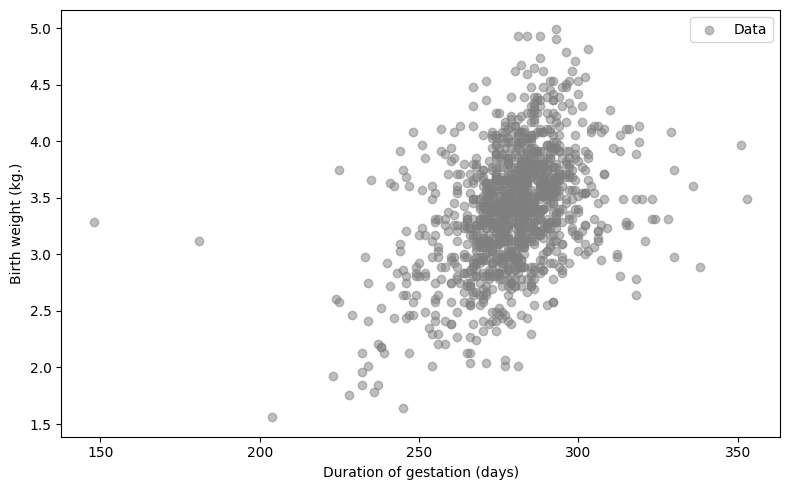

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x,y, alpha=0.5, label="Data", color="tab:grey")
plt.xlabel("Duration of gestation (days)")
plt.ylabel("Birth weight (kg.)")
plt.legend()
plt.tight_layout()
plt.show()

## Local regression
Local regression is also known as Lowess (https://en.wikipedia.org/wiki/Local_regression).

In [5]:
def tricube(u):
    """Tricube kernel D(|u|) = (1 - |u|^3)^3 for |u|<=1, else 0."""
    abs_u = np.abs(u)
    w = np.where(abs_u < 1, (1 - abs_u**3)**3, 0.0)
    return w

def lowess(x, y, lam=1.0, x_eval=None):
    """
    LOWESS with fixed metric bandwidth λ (tricube kernel, local linear).

    Parameters
    ----------
    x, y : 1-D arrays (data)
    lam  : bandwidth (same units as x)
    x_eval : points to evaluate the smooth (default = sorted x)

    Returns
    -------
    x_eval (sorted), y_smooth
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if x_eval is None:
        x_eval = np.sort(x)
    x_eval = np.asarray(x_eval)

    y_smooth = np.empty_like(x_eval, dtype=float)

    for idx, x0 in enumerate(x_eval):
        # distances from x0
        d = x - x0
        u = d / lam                     # scaled distance
        w = tricube(u)                  # tricube weights
        if w.sum() == 0:                # no points in window (unlikely if λ>0)
            y_smooth[idx] = np.nan
            continue

        # Local linear regression (center x at x0 for stability)
        X_loc = np.vstack([np.ones_like(x), d]).T
        W = np.diag(w)
        XtWX = X_loc.T @ W @ X_loc
        XtWy = X_loc.T @ W @ y
        beta_hat = np.linalg.pinv(XtWX) @ XtWy
        alpha_hat = beta_hat[0]         # prediction at x0 (d=0 ⇒ x-centered)
        y_smooth[idx] = alpha_hat

    return x_eval, y_smooth

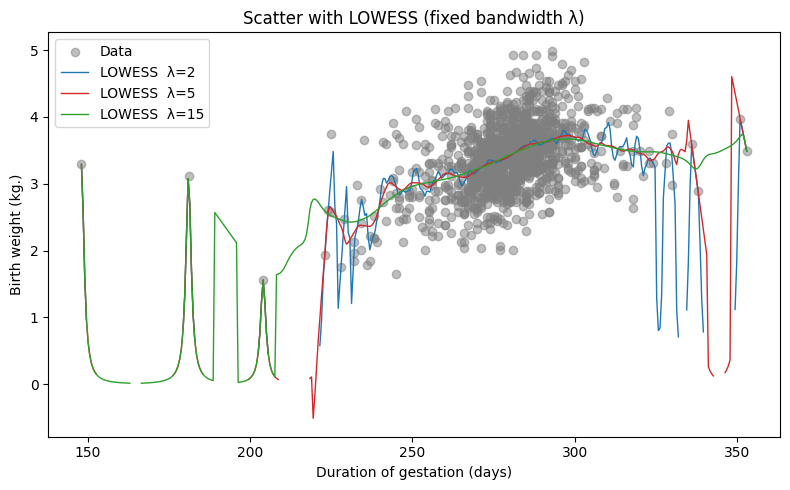

In [6]:
# ------------------------------------------------------------
# Choose λ and evaluate on a dense grid
# ------------------------------------------------------------
x_grid = np.linspace(x.min(), x.max(), 400)
x_s1, y_s1 = lowess(x, y, lam=2, x_eval=x_grid)
x_s2, y_s2 = lowess(x, y, lam=5, x_eval=x_grid)
x_s3, y_s3 = lowess(x, y, lam=15, x_eval=x_grid)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, color="tab:grey", label="Data")
plt.plot(x_s1, y_s1, color="tab:blue", lw=1, label=f"LOWESS  λ={2}")
plt.plot(x_s2, y_s2, color="tab:red", lw=1, label=f"LOWESS  λ={5}")
plt.plot(x_s3, y_s3, color="tab:green", lw=1, label=f"LOWESS  λ={15}")
plt.xlabel("Duration of gestation (days)")
plt.ylabel("Birth weight (kg.)")
plt.title("Scatter with LOWESS (fixed bandwidth λ)")
plt.legend()
plt.tight_layout()
plt.show()

## Kernel density estimation


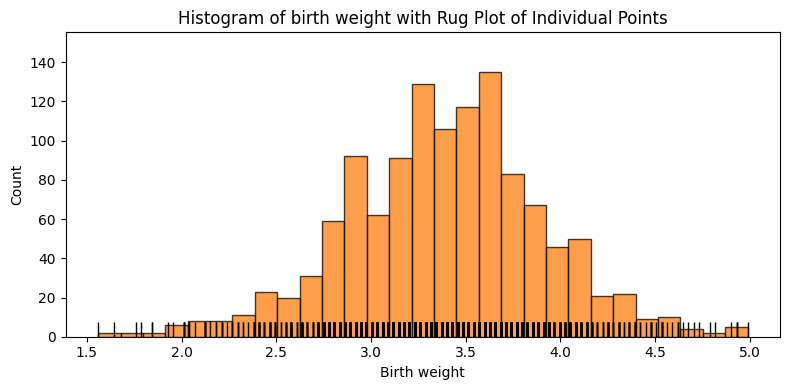

In [7]:
# ------------------------------------------------------------
# Histogram + rug plot of the points
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

# Histogram of y
plt.hist(
    y,
    bins="auto",          # choose bin algorithm; or set an int
    color="tab:orange",
    edgecolor="k",
    alpha=0.75
)

# Rug marks (one tick per observation)
sns.rugplot(y, height=0.05, color="k")   # height controls tick length

plt.xlabel("Birth weight")
plt.ylabel("Count")
plt.title("Histogram of birth weight with Rug Plot of Individual Points")
plt.tight_layout()
plt.show()

In [11]:
def KDE(y, sigma):
  from scipy.stats import norm
  x_grid = np.linspace(y.min() - 3*sigma, y.max() + 3*sigma, 400)
  kernels = norm(loc=y[:, None], scale=sigma).pdf(x_grid)   # shape (n, len(x_grid))
  density = kernels.mean(axis=0)                            # average of bumps
  return x_grid, density, kernels

def plotKDE(y, sigma):
  x_grid, density, kernels = KDE(y, sigma)
  plt.figure(figsize=(8, 4))

  # Light grey individual bumps
  for k in kernels:
      plt.plot(x_grid, k/max(k)*0.1, color='grey', linewidth=0.7, alpha=0.6)

  # KDE (blue)
  plt.plot(x_grid, density, color='tab:blue', linewidth=2.0, label=r'$\hat f_\sigma(x)$')

  # Histogram for reference (optional)
  plt.hist(y, bins='auto', density=True,
          alpha=0.25, color='tab:orange', edgecolor='k',
          label='Histogram (density)')

  plt.xlabel("y")
  plt.ylabel("Density")
  plt.title(f"Gaussian Kernel Density Estimate (σ = {sigma})")
  plt.legend()
  plt.tight_layout()
  plt.show()

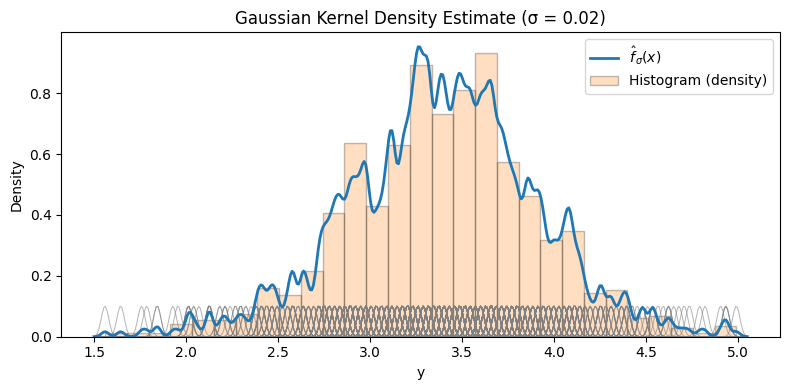

In [12]:
plotKDE(y, 0.02)

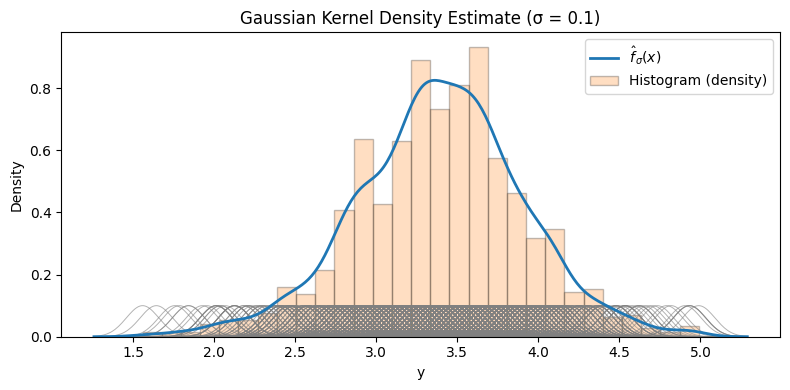

In [10]:
plotKDE(y,0.1)

## Naive Bayes
We will try to predict now whether the baby will have a weight below or above the average based on its mother's characteristics.



In [23]:
df = pd.read_csv("https://raw.githubusercontent.com/cossorzano/COSS_DataAnalysis_notebooks/refs/heads/main/MachineLearning/03_babies.csv")
df = df.dropna().drop(['case', 'gestation'], axis=1)
df["bwt"]*=0.0283495 # From ounces to kg.
df["height"]*=2.54 # From inches to cm.
df["weight"]*=0.453592
thBwt = df["bwt"].mean()
df["aboveMean"]=(df["bwt"]>thBwt).astype(int)
print(df)
print(f"Bwt threshold: {thBwt}")

# parity = 0 if 1st pregnancy, otherwise 1
# smoke = 0 if the mother does not smoke

           bwt  parity   age  height     weight  smoke  aboveMean
0     3.401940       0  27.0  157.48  45.359200    0.0          1
1     3.203493       0  33.0  162.56  61.234920    0.0          0
2     3.628736       0  28.0  162.56  52.163080    1.0          1
4     3.061746       0  23.0  170.18  56.699000    1.0          0
5     3.855532       0  25.0  157.48  42.184056    0.0          1
...        ...     ...   ...     ...        ...    ...        ...
1231  3.203493       1  27.0  152.40  45.359200    0.0          0
1232  3.628736       0  24.0  170.18  54.431040    0.0          1
1233  3.685435       0  30.0  165.10  68.038800    1.0          1
1234  3.543687       1  21.0  165.10  49.895120    0.0          1
1235  3.316892       0  38.0  165.10  58.513368    0.0          0

[1174 rows x 7 columns]
Bwt threshold: 3.386702747444634


In [24]:
class NaiveBayesKDE:
    """
    Hand-built Naive Bayes:
      • continuous features  -> Gaussian KDE  (one per class per feature)
      • discrete features    -> empirical P(X = v | class)
    """
    def __init__(self, cont_cols, disc_cols, sigma=0.5):
        self.cont_cols = cont_cols
        self.disc_cols = disc_cols
        self.sigma = sigma
        self.classes_ = None
        self.priors_ = {}                      # P(class)
        self.kde_grid_  = {}                   # {class: {feature: grid}}
        self.kde_dens_  = {}                   # {class: {feature: density(grid)}}
        self.disc_prob_ = {}                   # {class: {feature: {value: prob}}}

    # --------------------------------------------------------------
    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        n = len(y)
        for c in self.classes_:
            # Prior
            idx = (y == c).values if isinstance(y, pd.Series) else (y == c)
            self.priors_[c] = idx.mean()

            # --- Continuous KDEs
            self.kde_grid_[c] = {}
            self.kde_dens_[c] = {}
            for col in self.cont_cols:
                grid, dens, _ = KDE(X.loc[idx, col].values, self.sigma)
                self.kde_grid_[c][col] = grid
                self.kde_dens_[c][col] = dens

            # --- Discrete probabilities  P(X=val | class=c)
            self.disc_prob_[c] = {}
            for col in self.disc_cols:
                counts = X.loc[idx, col].value_counts(dropna=False)
                probs = counts / counts.sum()
                self.disc_prob_[c][col] = probs.to_dict()

    # --------------------------------------------------------------
    def _cont_likelihood(self, x_value, grid, density):
        # Fast lookup via linear interpolation of KDE curve
        return np.interp(x_value, grid, density, left=1e-12, right=1e-12)

    def predict_proba_row(self, row):
        """Return dict {class: posterior} for one row."""
        post = {}
        for c in self.classes_:
            # Start with prior
            log_prob = np.log(self.priors_[c])

            # Continuous features
            for col in self.cont_cols:
                lik = self._cont_likelihood(row[col],
                                            self.kde_grid_[c][col],
                                            self.kde_dens_[c][col])
                log_prob += np.log(lik + 1e-12)   # add eps to avoid log(0)

            # Discrete features
            for col in self.disc_cols:
                val = row[col]
                prob = self.disc_prob_[c][col].get(val, 1e-12)
                log_prob += np.log(prob)

            post[c] = log_prob

        # Convert log-posterior to probabilities
        max_log = max(post.values())
        exp_shifted = {c: np.exp(l - max_log) for c, l in post.items()}
        total = sum(exp_shifted.values())
        return {c: v / total for c, v in exp_shifted.items()}

    # --------------------------------------------------------------
    def predict(self, X):
        preds = []
        for _, row in X.iterrows():
            post = self.predict_proba_row(row)
            preds.append(max(post, key=post.get))
        return np.array(preds)

    def predict_probabilities(self, X):
        prob_matrix = []
        for _, row in X.iterrows():
            prob_matrix.append([self.predict_proba_row(row)[c] for c in self.classes_])
        return np.array(prob_matrix)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

cont_cols = ["age", "weight", "height"]
disc_cols = ["parity", "smoke"]

X = df[cont_cols + disc_cols]
y = df["aboveMean"]

nb_kde = NaiveBayesKDE(cont_cols, disc_cols, sigma=1.0)   # adjust σ if needed
nb_kde.fit(X, y)

y_pred = nb_kde.predict(X)
acc = accuracy_score(y, y_pred)
cm  = confusion_matrix(y, y_pred, labels=[0,1])

print(f"Accuracy: {acc:.3f}")
print("Confusion matrix (rows = true, cols = pred):\n", cm)


Accuracy: 0.634
Confusion matrix (rows = true, cols = pred):
 [[332 244]
 [186 412]]


In [27]:
p_pred = nb_kde.predict_probabilities(X)
print(p_pred)

[[0.64167966 0.35832034]
 [0.36279488 0.63720512]
 [0.67261276 0.32738724]
 ...
 [0.52586992 0.47413008]
 [0.50388573 0.49611427]
 [0.30628027 0.69371973]]
